Build LLM Powered Chatbot Using Langgraph

In [8]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
#Reducer
from typing import Annotated
from langgraph.graph.message import add_messages

import os
from dotenv import load_dotenv

from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq

from IPython.display import Image, display

In [2]:
class State(TypedDict):
    
    messages:Annotated[list, add_messages]

In [3]:
load_dotenv()

os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')

In [4]:
llm = ChatOpenAI(model='gpt-4o')
llm.invoke('Hello')

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_f986a632b0', 'id': 'chatcmpl-DJdO8362MrbU0IKltjtgl3kr7kECJ', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--019cf120-a833-74a3-9972-2be39c488bab-0', usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [5]:
# Using the newer Gemma 2 model
llm_groq = ChatGroq(model='gemma2-9b-it')

llm_groq = ChatGroq(model='llama-3.1-8b-instant')

response = llm_groq.invoke('Hi, I am Saheed, i love to code in python')
print(response.content)

Nice to meet you, Saheed! Python is an excellent language to work with, and it's widely used in various fields such as data science, machine learning, web development, and automation.

What do you enjoy about coding in Python? Are you working on any projects or interested in exploring a particular area of Python development?

If you're looking for resources or want to improve your coding skills, I can suggest some popular libraries, frameworks, and tutorials that you might find helpful.

Some popular Python libraries and frameworks include:

1. NumPy and Pandas for data analysis and manipulation.
2. Flask and Django for web development.
3. Scikit-learn and TensorFlow for machine learning.
4. Requests and BeautifulSoup for web scraping.

Let me know if you'd like more information or resources, and I'd be happy to help!


Create Nodes

In [6]:
def smartBot(state:State):
    # We pass the messages from the state to the LLM and return the response as a new message in the state.
    return {
        'messages': [llm_groq.invoke(state['messages'])] # 
    }

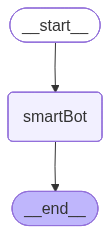

In [9]:
graph = StateGraph(State) # Initialize the graph with the State type

# Add nodes to the graph
graph.add_node('smartBot', smartBot)

# Define the edges between the nodes
graph.add_edge(START, 'smartBot')
graph.add_edge('smartBot', END)

# Compile the graph
graph_builder = graph.compile()

# Display the graph
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [11]:
# Execute the graph with invokation
result = graph_builder.invoke({
    'messages': 'Hello, how are you?. I love django and python'
})

print(result)

{'messages': [HumanMessage(content='Hello, how are you?. I love django and python', additional_kwargs={}, response_metadata={}, id='327d5ce2-c78c-412a-846d-63e1f1bb1e81'), AIMessage(content="Hello. I'm doing well, thank you for asking. It's great to hear that you're interested in Django and Python. They are both popular and powerful tools for web development. Django is a high-level Python web framework that enables rapid development of secure, maintainable, and scalable websites.\n\nPython, on the other hand, is a versatile and easy-to-learn programming language that's widely used in web development, data science, artificial intelligence, and more. Its simplicity and flexibility make it a great choice for beginners and experienced developers alike.\n\nWhat specific areas of Django and Python are you interested in? Are you working on a project or looking to learn more about a particular topic?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 138, 'prompt_t

In [15]:
# Streaming response from the graph
graph_builder_stream = graph_builder.stream({
    'messages': 'Hello, how are you?. I love django and python'
}, stream_mode='values'
)

graph_builder_stream

for event in graph_builder_stream:
    print(event)

{'messages': [HumanMessage(content='Hello, how are you?. I love django and python', additional_kwargs={}, response_metadata={}, id='caf82c5d-b9a7-43c4-93b4-a7562587d4d1')]}
{'messages': [HumanMessage(content='Hello, how are you?. I love django and python', additional_kwargs={}, response_metadata={}, id='caf82c5d-b9a7-43c4-93b4-a7562587d4d1'), AIMessage(content="Hello. I'm doing well, thank you for asking. It's great to hear that you enjoy Django and Python. Django is a fantastic web framework for building robust and scalable web applications, and Python is an excellent language for development.\n\nWhat specific aspects of Django or Python are you interested in? Are you working on a project, or do you have any questions or topics you'd like to discuss?\n\nSome popular topics in Django include:\n\n- Project setup and structure\n- Models and database interactions\n- Views and URL routing\n- Templates and static files\n- Authentication and authorization\n\nIn Python, some popular topics in

In [17]:
# Streaming response from the graph
graph_builder_stream = graph_builder.stream({
    'messages': 'Hello, how are you?. I love django and python'
}, stream_mode='updates'
)

graph_builder_stream

for event in graph_builder_stream:
    print(event)

{'smartBot': {'messages': [AIMessage(content="Hello. I'm doing well, thank you for asking. Django and Python are indeed fantastic technologies, especially for web development. Django is a high-level, open-source Python web framework that helps developers build robust, scalable, and maintainable web applications quickly.\n\nPython, on the other hand, is a versatile and easy-to-learn programming language that's widely used in various fields such as web development, data science, machine learning, automation, and more.\n\nWhat's your area of interest in Django and Python? Are you working on a project, or do you have any specific questions or topics you'd like to discuss?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 125, 'prompt_tokens': 46, 'total_tokens': 171, 'completion_time': 0.179790082, 'prompt_time': 0.002136126, 'queue_time': 0.005415962, 'total_time': 0.181926208}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_03e8423237', 'ser